# Method comparison on synthetic data

Run every enhancement method ConnInfPy ships against the same ground-truth synthetic dataset and compare their `1 − p` maps side by side. This notebook is the interactive successor to the legacy `examples/sim_method_comparisons/sim_method_comparisons.py` CLI script.

**What you'll see.**

1. Build a ground-truth topology mask from `conninfpy.topologies` (default: within-module dense effect).
2. Generate two groups of correlation matrices using `ModularDatasetGenerator`.
3. Compute the signed t-statistic map on the Fisher-z transformed data.
4. Run `compute_p_val` with `method ∈ {tstat, tfnbs, nbs (extent), nbs (intensity), cnbs, ni_tfnbs, fbc_tfnbs}`.
5. Plot a panel of ground-truth + t-stat + per-method `1 − p` maps with TP / FN / FP overlays.

Runtime ≲ 1 minute on default settings (60 nodes, 30 + 30 subjects, 200 permutations).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import compute_p_val, compute_t_stat, fisher_r_to_z
from conninfpy import topologies as topo

## 1. Settings

Edit these to explore other topologies, sample sizes, or methods. Available scenarios live in `topo.list_scenarios()`.

In [2]:
SCENARIO = "within_module_dense"   # try also: between_module_dense, hub, rich_club, ...
N_NODES = 60
N_MODULES = 4
N_SAMPLES = 30                     # per group
TIME_POINTS = 120
EFFECT_SIZE = 0.25
N_PERM = 200
ALPHA = 0.05
E, H, N_THRESH = 0.4, 3.0, 10      # Hao 2024 FDR-calibrated regime
NBS_THRES = 2.0
SEED = 42

print("available scenarios:", topo.list_scenarios())

available scenarios: ['within_module_dense', 'between_modules_dense', 'hub', 'chain', 'fragmented_within_module', 'multi_cluster_within_module', 'checkerboard_within_module', 'scattered_cross_block', 'uniform_base_modular_effect', 'within_plus_between', 'perfect_matching_within_module', 'cross_block_connected_chain', 'rich_club', 'two_equal_disconnected_cliques', 'focal_clique_inside_module', 'partial_bipartite_between_modules', 'gradient_effect_chain', 'gradient_core_periphery_within_module', 'imbalanced_modules_within_effect']


## 2. Build the synthetic dataset

In [3]:
scenario = topo.get_scenario(SCENARIO)
gen = topo.TopologyDatasetGenerator(
    n_nodes=N_NODES,
    n_modules=N_MODULES,
    seed=SEED,
)
ds = gen.generate(
    scenario,
    effect_size=EFFECT_SIZE,
    n_samples=N_SAMPLES,
    time_points=TIME_POINTS,
)

print(f"group1: {ds.group1.shape}, group2: {ds.group2.shape}")
print(f"effect_mask: {ds.effect_mask.sum()} planted edges; net_labels K={ds.net_labels.max() + 1}")

group1: (30, 60, 60), group2: (30, 60, 60)
effect_mask: 105.0 planted edges; net_labels K=4


## 3. Signed t-statistic on Fisher-z data

In [4]:
g1_z = fisher_r_to_z(ds.group1)
g2_z = fisher_r_to_z(ds.group2)

t_dict = compute_t_stat(g1_z, g2_z, test_type="two-sample")
t_signed = t_dict["positive"] - t_dict["negative"]
print("t-stat range:", t_signed.min(), t_signed.max())

t-stat range: -3.1943577965176413 10.003297072578901


## 4. Run every enhancement method

Each call returns an `InferenceResult` with per-tail p-value maps. We collapse to a single `min(p_positive, p_negative)` map per method for the side-by-side plot.

In [5]:
def _two_tail_p(result):
    return np.minimum(result["positive"], result["negative"])

common = dict(test_type="two-sample", n_permutations=N_PERM, rng=SEED, use_mp=True)
tfce_kw = dict(e=E, h=H, n=N_THRESH, start_thres=1.65)

p_maps = {}
p_maps["tstat"] = _two_tail_p(compute_p_val(g1_z, g2_z, method="tstat", **common))
p_maps["tfnbs"] = _two_tail_p(compute_p_val(g1_z, g2_z, method="tfnbs", **tfce_kw, **common))
p_maps["nbs_extent"] = _two_tail_p(
    compute_p_val(g1_z, g2_z, method="nbs", threshold=NBS_THRES, nbs_stat="extent", **common)
)
p_maps["nbs_intensity"] = _two_tail_p(
    compute_p_val(g1_z, g2_z, method="nbs", threshold=NBS_THRES, nbs_stat="intensity", **common)
)
p_maps["cnbs"] = _two_tail_p(
    compute_p_val(g1_z, g2_z, method="cnbs", net_labels=ds.net_labels, **common)
)
p_maps["ni_tfnbs"] = _two_tail_p(
    compute_p_val(g1_z, g2_z, method="ni_tfnbs", net_labels=ds.net_labels, **tfce_kw, **common)
)
p_maps["fbc_tfnbs"] = _two_tail_p(
    compute_p_val(
        g1_z, g2_z, method="fbc_tfnbs",
        net_labels=ds.net_labels, min_cluster_size=3, **tfce_kw, **common,
    )
)
for name, p in p_maps.items():
    print(f"{name:14s}  significant edges @ α={ALPHA}: {int((p <= ALPHA).sum() // 2)}")

tstat           significant edges @ α=0.05: 100
tfnbs           significant edges @ α=0.05: 105
nbs_extent      significant edges @ α=0.05: 173
nbs_intensity   significant edges @ α=0.05: 173
cnbs            significant edges @ α=0.05: 105
ni_tfnbs        significant edges @ α=0.05: 104
fbc_tfnbs       significant edges @ α=0.05: 104


## 5. TP / FN / FP overlay against the planted ground truth

In [6]:
def _tp_fn_fp(p_map, gt_mask, alpha):
    tri = np.triu_indices(p_map.shape[0], k=1)
    sig = p_map[tri] <= alpha
    truth = gt_mask[tri] != 0
    tp = int(np.sum(sig & truth))
    fn = int(np.sum(~sig & truth))
    fp = int(np.sum(sig & ~truth))
    return tp, fn, fp

scores = {name: _tp_fn_fp(p, ds.effect_mask, ALPHA) for name, p in p_maps.items()}
for name, (tp, fn, fp) in scores.items():
    print(f"{name:14s}  TP={tp:3d}  FN={fn:3d}  FP={fp:4d}")

tstat           TP=100  FN=  5  FP=   0
tfnbs           TP=104  FN=  1  FP=   1
nbs_extent      TP=105  FN=  0  FP=  68
nbs_intensity   TP=105  FN=  0  FP=  68
cnbs            TP=105  FN=  0  FP=   0
ni_tfnbs        TP=104  FN=  1  FP=   0
fbc_tfnbs       TP=104  FN=  1  FP=   0


## 6. Side-by-side plot of `1 − p` per method

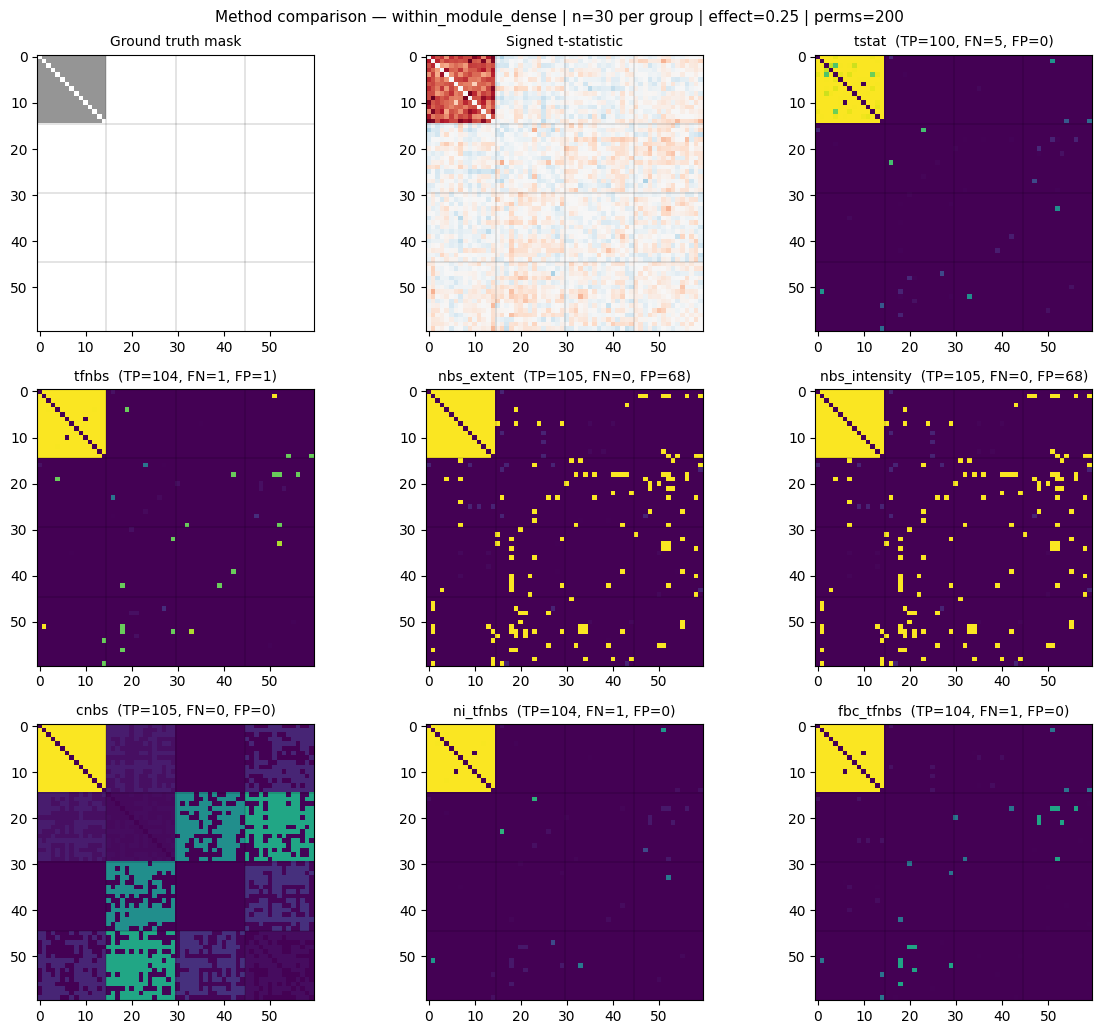

In [7]:
def _draw_module_boundaries(ax, labels):
    boundaries = np.where(np.diff(labels) != 0)[0] + 0.5
    for b in boundaries:
        ax.axvline(b, color="black", linewidth=0.3, alpha=0.5)
        ax.axhline(b, color="black", linewidth=0.3, alpha=0.5)

methods = list(p_maps.keys())
n_panels = 2 + len(methods)
ncols = 3
nrows = (n_panels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = np.array(axes).ravel()

axes[0].imshow(ds.effect_mask, cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("Ground truth mask", fontsize=10)
_draw_module_boundaries(axes[0], ds.net_labels)

vlim = float(np.max(np.abs(t_signed)))
axes[1].imshow(t_signed, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
axes[1].set_title("Signed t-statistic", fontsize=10)
_draw_module_boundaries(axes[1], ds.net_labels)

for ax, name in zip(axes[2:], methods):
    p = p_maps[name]
    ax.imshow(1.0 - p, cmap="viridis", vmin=0.0, vmax=1.0)
    tp, fn, fp = scores[name]
    ax.set_title(f"{name}  (TP={tp}, FN={fn}, FP={fp})", fontsize=10)
    _draw_module_boundaries(ax, ds.net_labels)

for ax in axes[n_panels:]:
    ax.axis("off")

fig.suptitle(
    f"Method comparison — {scenario.name} | n={N_SAMPLES} per group | "
    f"effect={EFFECT_SIZE} | perms={N_PERM}",
    fontsize=11,
)
fig.tight_layout()
plt.show()

## What to try next

- Swap `SCENARIO` for `between_module_dense`, `hub`, `rich_club`, `scattered`, `gradient`, `bipartite`, `fragmented`, `core_periphery`, or `cross_block_chain` to see which methods specialise where.
- Increase `N_PERM` to 1000–5000 for production-quality p-values (this notebook caps it at 200 for runtime).
- Add `acceleration='gpd'` to the `compute_p_val` calls for 25× wall-time savings at the same FWER.
- For multi-comparison plots across scenarios, see `examples/simulation_validation/` for the full sweep harness.